# Source A — What the Shape of an Article Knows

**The question:** how much of a county can be read off the *structure* of its
Wikipedia article — how many sections it has, how long they are, which ones are
present — without reading a word of the text?

**The prior:** the answer is "county size". `n_body_sections` was computed
during the section round, correlated r = 0.550 against log tax returns, and cut
from the scored block for exactly that reason. This notebook is built so that
prior can be checked rather than assumed: the size audit runs before the
scoring, and every arm sits on a baseline that already holds three size
measures.

Everything below is computed from committed artifacts. Nothing is typed in.

In [1]:
import json
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO = Path.cwd()
while not (REPO / "data").exists() and REPO != REPO.parent:
    REPO = REPO.parent
DATA, ANALYSIS, OUTPUTS = REPO / "data", REPO / "analysis-output", REPO / "outputs"
SOURCE_A = ANALYSIS / "source-a"

mpl.rcParams.update({"figure.figsize": (11, 5.5), "figure.dpi": 110, "axes.grid": True,
                     "axes.axisbelow": True, "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})

sections = pd.read_parquet(DATA / "source_a_sections.parquet")
features = pd.read_parquet(DATA / "source_a_structure_features.parquet")
feature_stats = json.loads((SOURCE_A / "source_a_structure_feature_stats.json").read_text())
scoring_stats = json.loads((SOURCE_A / "source_a_structure_stats.json").read_text())
scores = pd.read_csv(OUTPUTS / "source_a_structure_scores.csv")
by_pillar = pd.read_csv(OUTPUTS / "source_a_structure_by_pillar.csv")

print(f"{feature_stats['n_counties']:,} counties x {feature_stats['n_features']} structural features")
print(f"{len(sections):,} sections, {len(feature_stats['title_flag_vocabulary'])} title flags")

3,144 counties x 64 structural features
64,588 sections, 42 title flags


## Part one — what the corpus is shaped like

Three facts set up everything after them: how many sections an article has, how
unevenly its characters are spread across them, and how quickly the title
vocabulary thins out.

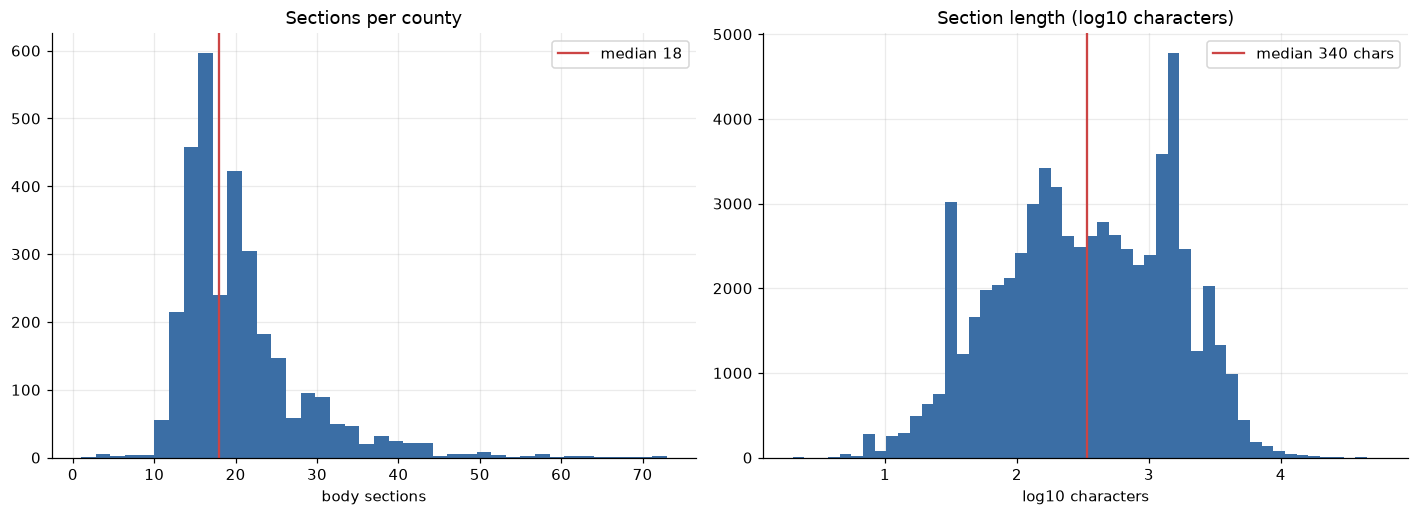

mean section length 848 chars, median 340, max 55,228
The mean sits well above the median: a handful of very long sections carry it.


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].hist(features["n_body_sections"], bins=40, color="#3b6ea5")
axes[0].set_title("Sections per county")
axes[0].set_xlabel("body sections")
axes[0].axvline(features["n_body_sections"].median(), color="#c44", lw=1.5,
                label=f"median {features['n_body_sections'].median():.0f}")
axes[0].legend()

section_chars = sections["section_text"].str.len()
axes[1].hist(np.log10(section_chars.clip(lower=1)), bins=50, color="#3b6ea5")
axes[1].set_title("Section length (log10 characters)")
axes[1].set_xlabel("log10 characters")
axes[1].axvline(np.log10(section_chars.median()), color="#c44", lw=1.5,
                label=f"median {section_chars.median():,.0f} chars")
axes[1].legend()

fig.tight_layout()
plt.show()

print(f"mean section length {section_chars.mean():,.0f} chars, median {section_chars.median():,.0f}, "
      f"max {section_chars.max():,.0f}")
print("The mean sits well above the median: a handful of very long sections carry it.")

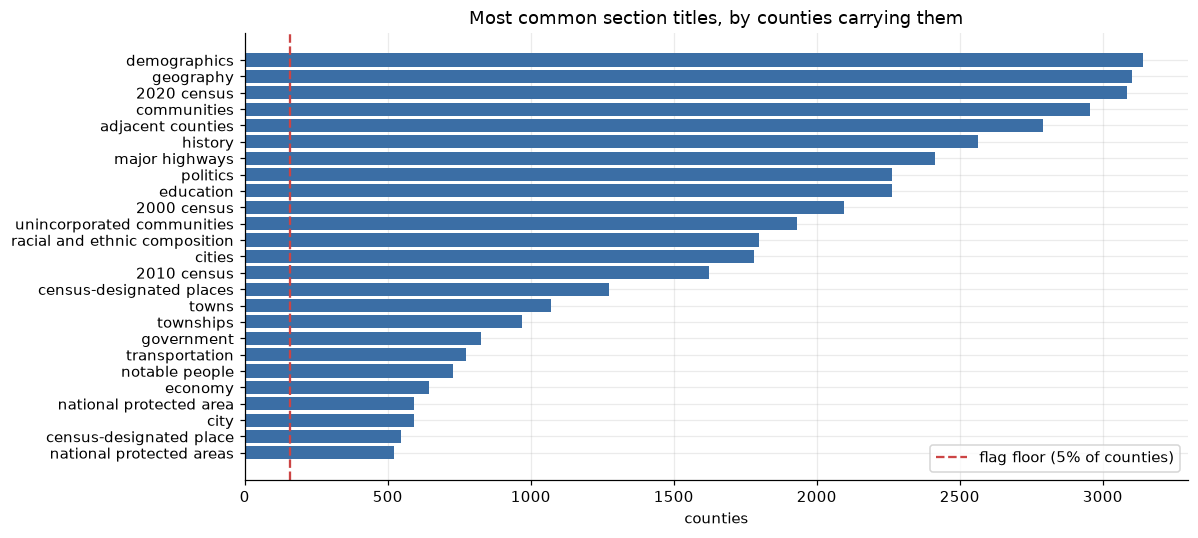

4,021 distinct titles; 42 clear the floor.


In [3]:
titles = sections["section_title"].fillna("").str.strip().str.lower()
per_title = titles[titles != ""].groupby(titles[titles != ""]).size().sort_values(ascending=False)
county_counts = (sections.assign(t=titles).loc[titles != ""]
                 .groupby("t")["fips_code"].nunique().sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(11, 5))
top = county_counts.head(25)[::-1]
ax.barh(top.index, top.to_numpy(), color="#3b6ea5")
ax.axvline(feature_stats["title_flag_min_share"] * feature_stats["n_counties"], color="#c44",
           lw=1.5, ls="--", label=f"flag floor ({feature_stats['title_flag_min_share']:.0%} of counties)")
ax.set_title("Most common section titles, by counties carrying them")
ax.set_xlabel("counties")
ax.legend()
fig.tight_layout()
plt.show()

print(f"{len(county_counts):,} distinct titles; {len(feature_stats['title_flag_vocabulary'])} clear the floor.")

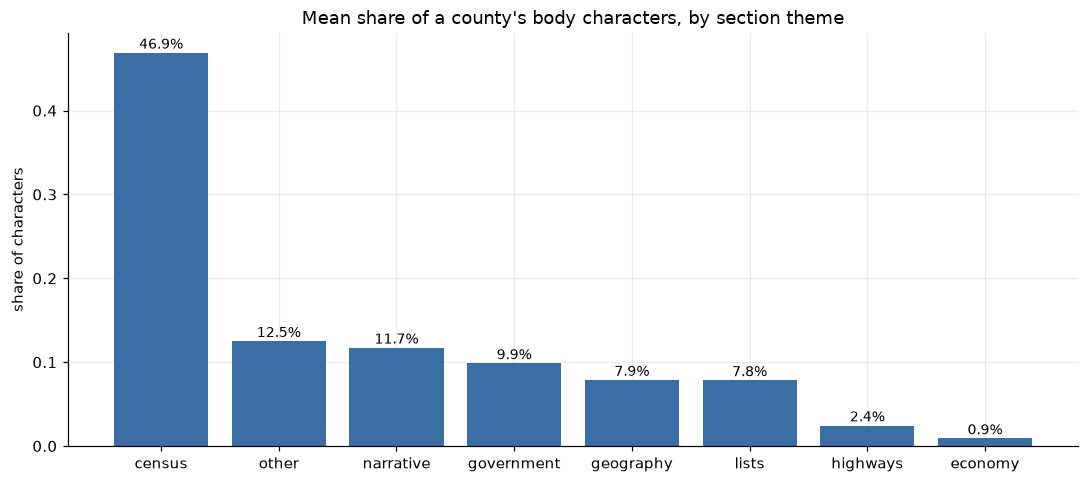

In [4]:
bucket_means = pd.Series(feature_stats["mean_bucket_share"]).sort_values(ascending=False)
bucket_means.index = [c.replace("share_chars_", "") for c in bucket_means.index]

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(bucket_means.index, bucket_means.to_numpy(), color="#3b6ea5")
ax.set_title("Mean share of a county's body characters, by section theme")
ax.set_ylabel("share of characters")
for x, y in zip(bucket_means.index, bucket_means.to_numpy()):
    ax.text(x, y + 0.005, f"{y:.1%}", ha="center", fontsize=9)
fig.tight_layout()
plt.show()

## Part two — the size-proxy audit

This runs before the scoring, on purpose. Most of these columns are ways of
measuring how much has been written about a county, and how much has been
written about a county is mostly how big it is. The columns that correlate
*weakly* with all three size measures are the ones with anything left to
contribute once the baseline has taken its share.

Three size measures, not one: `n_body_sections` was cut on its correlation with
log tax returns specifically, and a table showing only population would have
understated it.

In [5]:
import sys
sys.path.insert(0, str(REPO / "scripts"))
from pillar_matrix import SIZE_FEATURES, build_matrix

matrix, _ = build_matrix()
merged = matrix[["fips_code", *SIZE_FEATURES]].merge(features, on="fips_code", how="inner")
structure_cols = [c for c in features.columns if c != "fips_code"]

correlations = pd.DataFrame(
    {size: merged[structure_cols].corrwith(merged[size]) for size in SIZE_FEATURES}
)
correlations["max_abs"] = correlations.abs().max(axis=1)
correlations = correlations.sort_values("max_abs", ascending=False)

print("Most size-dependent structural columns:")
display(correlations.head(12).round(3))
print("\nLeast size-dependent — the columns with headroom:")
display(correlations.tail(12).round(3))

Most size-dependent structural columns:


,log_population,log_agi,log_gdp_latest,max_abs
n_distinct_titles,0.548,0.549,0.545,0.549
n_body_sections,0.546,0.546,0.543,0.546
max_section_id,0.545,0.544,0.541,0.545
share_chars_census,-0.465,-0.457,-0.438,0.465
total_body_chars,0.425,0.433,0.447,0.447
share_in_largest_section,-0.434,-0.426,-0.425,0.434
share_chars_other,0.392,0.390,0.376,0.392
share_stub_sections,-0.360,-0.370,-0.382,0.382
has_section_transportation,0.374,0.378,0.371,0.378
median_section_chars,0.297,0.311,0.330,0.330



Least size-dependent — the columns with headroom:


,log_population,log_agi,log_gdp_latest,max_abs
has_section_town,-0.079,-0.086,-0.087,0.087
has_section_villages,0.075,0.084,0.071,0.084
has_section_2000_census,-0.072,-0.080,-0.061,0.080
has_section_major_highways,-0.070,-0.074,-0.058,0.074
has_section_ghost_towns,-0.056,-0.050,-0.023,0.056
has_section_townships,-0.053,-0.033,-0.040,0.053
share_chars_narrative,0.045,0.032,0.038,0.045
share_chars_lists,-0.016,-0.007,-0.042,0.042
has_section_climate_and_weather,0.033,0.041,0.025,0.041
has_section_elected_officials,0.040,0.019,-0.005,0.040


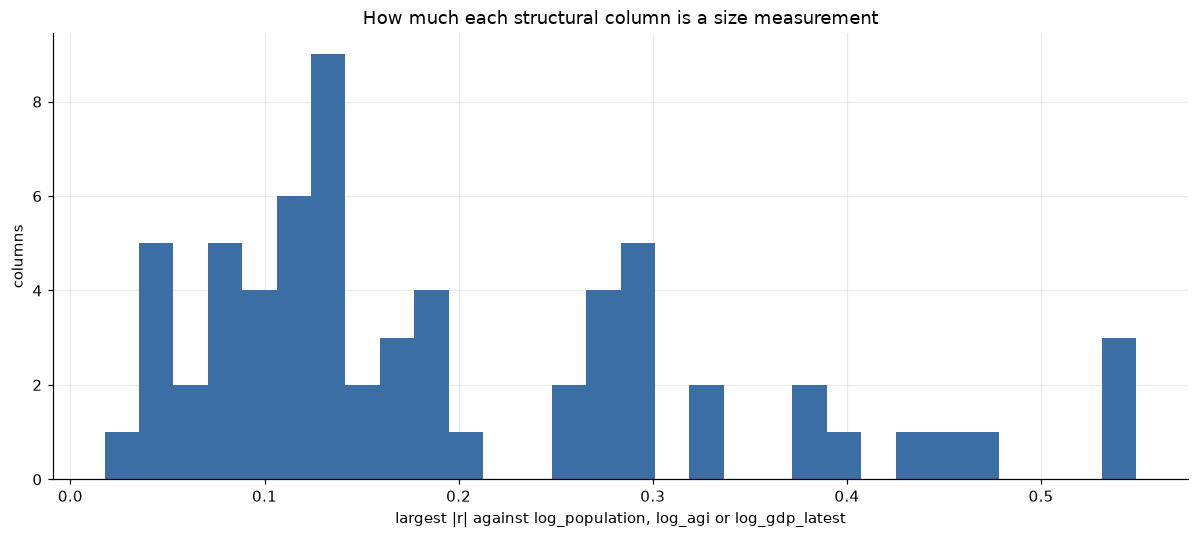

6 of 64 columns correlate above |r| = 0.4 with at least one size measure.


In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(correlations["max_abs"], bins=30, color="#3b6ea5")
ax.set_title("How much each structural column is a size measurement")
ax.set_xlabel("largest |r| against log_population, log_agi or log_gdp_latest")
ax.set_ylabel("columns")
fig.tight_layout()
plt.show()

n_strong = int((correlations["max_abs"] > 0.4).sum())
print(f"{n_strong} of {len(correlations)} columns correlate above |r| = 0.4 with at least one size measure.")

## Part three — the four arms

Every arm sits on the same unpenalized baseline of three size measures plus
state fixed effects, and is fitted to that baseline's residuals with a ridge
whose penalty is chosen by nested crossvalidation. Identical folds, identical
rows, five folds, seed 42. A block that knows nothing therefore costs
approximately nothing rather than dragging the controls down.

In [7]:
arms = pd.DataFrame(scoring_stats["arms"]).T
display(arms[["label", "compared_against", "mean_lift", "mean_paired_difference", "n_wins", "wilcoxon_p"]])

print(f"{scoring_stats['n_targets']} targets | "
      f"{scoring_stats['n_structure_features']} structural columns vs "
      f"{scoring_stats['n_typed_features']} shipped typed columns")

,label,compared_against,mean_lift,mean_paired_difference,n_wins,wilcoxon_p
structure,structural block (shape only),baseline,0.002686,0.002686,21,0.001172
typed,shipped 29 typed columns,baseline,0.003072,0.003072,22,0.000381
typed_plus_structure,typed columns + structural block,typed,0.004908,0.001836,20,0.011839


28 targets | 64 structural columns vs 29 shipped typed columns


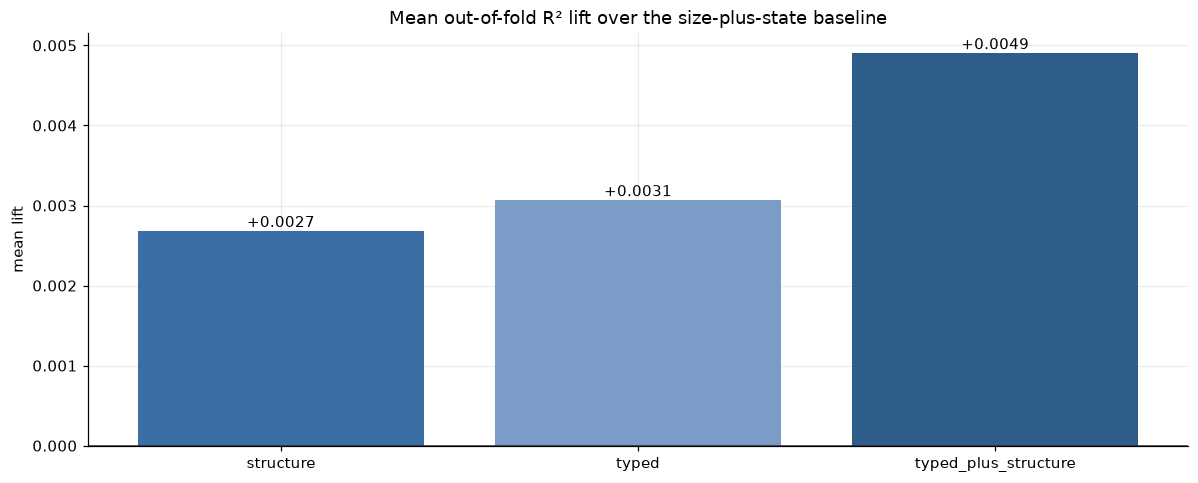

In [8]:
fig, ax = plt.subplots(figsize=(11, 4.5))
keys = list(scoring_stats["arms"])
values = [scoring_stats["arms"][k]["mean_lift"] for k in keys]
ax.bar(keys, values, color=["#3b6ea5", "#7a9cc6", "#2f5d8a"])
ax.axhline(0, color="#333", lw=1)
ax.set_title("Mean out-of-fold R² lift over the size-plus-state baseline")
ax.set_ylabel("mean lift")
for x, y in zip(keys, values):
    ax.text(x, y, f"{y:+.4f}", ha="center", va="bottom" if y >= 0 else "top", fontsize=10)
fig.tight_layout()
plt.show()

### Per-pillar, because the aggregate is a property of the basket

Twenty of the twenty-eight targets are one QCEW table. A basket-wide mean is
therefore 71% one pillar, and reading it as a breadth claim is a mistake this
project has made before.

,pillar,n_targets,structure,typed,typed_plus_structure
0,B,20,0.00314,0.00244,0.00497
1,C,3,0.00130,0.00180,0.00298
2,D,3,0.00000,0.00153,0.00079
3,E,1,0.00179,0.00530,0.00447
4,F,1,0.00671,0.02182,0.02217


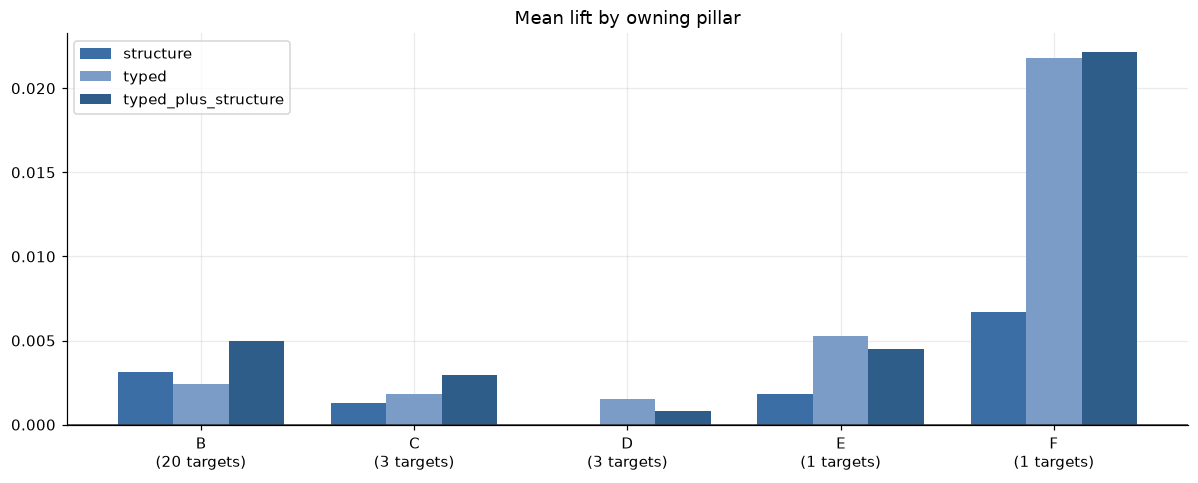

In [9]:
display(by_pillar.round(5))

fig, ax = plt.subplots(figsize=(11, 4.5))
width = 0.26
x = np.arange(len(by_pillar))
for offset, key, color in zip((-width, 0, width), keys, ("#3b6ea5", "#7a9cc6", "#2f5d8a")):
    ax.bar(x + offset, by_pillar[key], width, label=key, color=color)
ax.set_xticks(x)
ax.set_xticklabels([f"{p}\n({n} targets)" for p, n in zip(by_pillar["pillar"], by_pillar["n_targets"])])
ax.axhline(0, color="#333", lw=1)
ax.set_title("Mean lift by owning pillar")
ax.legend()
fig.tight_layout()
plt.show()

In [10]:
best = scores.head(10)[["pillar", "label", "n", "r2_baseline", "lift_structure", "lift_typed",
                        "lift_typed_plus_structure"]]
print("Targets where article shape helps most:")
display(best.round(4))

worst = scores.tail(5)[["pillar", "label", "lift_structure", "lift_typed"]]
print("\nAnd where it hurts most:")
display(worst.round(4))

Targets where article shape helps most:


,pillar,label,n,r2_baseline,lift_structure,lift_typed,lift_typed_plus_structure
0,B,Accommodation & Food Services LQ,2369,0.1273,0.0255,0.0253,0.0478
1,B,Retail Trade LQ,3050,0.1118,0.0103,-0.0014,0.0056
2,F,demographic distress count,3144,0.2017,0.0067,0.0218,0.0222
3,B,Manufacturing LQ,2570,0.2153,0.0060,0.0058,0.0091
4,B,"Agriculture, Forestry, Fishing & Hunting LQ",1457,0.3362,0.0047,0.0004,0.0048
5,B,Educational Services LQ,1587,0.1161,0.0037,0.0001,0.0029
6,B,Information LQ,1914,0.0344,0.0037,0.0028,0.0078
7,C,unemployment rate (level),3143,0.5028,0.0034,0.0036,0.0063
8,B,Wholesale Trade LQ,2346,0.2191,0.0033,0.0021,0.0049
9,B,"Arts, Entertainment & Recreation LQ",2243,0.1706,0.0029,0.0017,0.0043



And where it hurts most:


,pillar,label,lift_structure,lift_typed
23,B,Construction LQ,-0.0004,0.0002
24,B,Real Estate & Rental & Leasing LQ,-0.0004,0.0023
25,B,Transportation & Warehousing LQ,-0.0006,0.0057
26,B,Administrative & Support & Waste Management LQ,-0.0011,-0.0009
27,B,Finance & Insurance LQ,-0.0022,0.0040


## What this round does and does not settle

- It does not propose shipping these columns. If `typed_plus_structure` beats
  `typed`, that is an argument for a follow-up round, not a change to
  `pillar_matrix`.
- It reads no section text. Any lexicon question belongs to the section-scope
  round, which already exists.
- It does not revisit the `n_body_sections` cut on its own authority. That
  decision stands unless the numbers above argue otherwise.